In [ ]:
import jax.numpy as jnp
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import cm
import jax
from jax import grad, vmap
import tqdm
import itertools
import numpy as np
from scipy.linalg import eig
from mpl_toolkits.mplot3d import axes3d
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
jax.config.update("jax_enable_x64", True)

In [ ]:
#Define 3D Gaussian kernel and derivatives


def kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  K = jnp.exp(-((s1-t1)**2/(2*sigma1**2))-((s2-t2)**2/(2*sigma2**2))- ((s3-t3)**2/(2*sigma3**2)))
  return K

def kernel_dx1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):

  return -(s1-t1)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma1**2)

def kernel_dy1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return -kernel_dx1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)


def kernel_dx2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return -(s2-t2)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma2**2)

def kernel_dy2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return -kernel_dx2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)

def kernel_dx3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return -(s3-t3)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma3**2)

def kernel_dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return -kernel_dx3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)


def kernel_dx1dy1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (sigma1**2-(s1-t1)**2)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma1**4)

def kernel_dx1dy2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (t2-s2)*(s1-t1)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma1**2*sigma2**2)

#----
def kernel_dx1dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (t3-s3)*(s1-t1)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma1**2*sigma3**2)
#----

def kernel_dx2dy1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return kernel_dx1dy2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)

def kernel_dx2dy2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (sigma2**2-(s2-t2)**2)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma2**4)

#----
def kernel_dx2dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (t3-s3)*(s2-t2)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma2**2*sigma3**2)

def kernel_dx3dy1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return kernel_dx1dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)

def kernel_dx3dy2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return kernel_dx2dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)

def kernel_dx3dy3(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3):
  return (sigma3**2-(s3-t3)**2)*kernel(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3)/(sigma3**4)

In [ ]:
# Finding equilibirum point of the gradient system

P = np.array([[2, 1, 0.5],
              [1, 3, 1],
              [0.5, 1, 5]])


# Define the function representing the gradient of V
def gradient_V(x_vec):
    x, y, z = x_vec
    # Linear component: 2 * P * x_vec
    linear_part = 2 * P @ x_vec
    # Nonlinear component from e^(x + y)
    exp_term = np.exp(x + y)
    nonlinear_part = np.array([exp_term, exp_term, 0])
    # Total gradient
    return linear_part + nonlinear_part

# Define the equilibrium function to find where gradient_V is zero
def equilibrium_func(x_vec):
    return gradient_V(x_vec)

# Initial guess for the equilibrium point
initial_guess = np.array([0.0, 0.0, 0.0])

# Solve for the equilibrium point
equilibrium_point = fsolve(equilibrium_func, initial_guess)

# Original equilibrium point
x_eq = equilibrium_point[0]
y_eq = equilibrium_point[1]
z_eq = equilibrium_point[2]

print(equilibrium_point)

# Define the gradient of the potential function with shifted coordinates
def grad_V_shifted(points):
    # Shift coordinates
    X_shifted = points[:, 0] + x_eq
    Y_shifted = points[:, 1] + y_eq
    Z_shifted = points[:, 2] + z_eq
    X_vec = np.stack([X_shifted, Y_shifted, Z_shifted], axis=-1)

    # Compute linear part of the gradient
    grad_linear = 2 * jnp.dot(X_vec, P.T)

    # Add nonlinear part of the gradient from exp(x + y) term
    exp_term = np.exp(X_shifted + Y_shifted)
    grad_exp = np.stack([exp_term, exp_term, np.zeros_like(exp_term)], axis=-1)

    # Total gradient
    grad = grad_linear + grad_exp
    return -grad


[-0.159488   -0.0881381   0.03357642]


In [ ]:
#Define Jacobian matrix E= dF(0)/dz at shifted eq.

# Linear
J_linear = 2 * P

# Nonlinear part at the shifted coordinates (u = x - x_e, v = y - y_e, w = z - z_e)
exp_term = np.exp(0 + x_eq + 0 + y_eq)

#Partial derivative of np.exp(x-x_eq+y-y_eq) with respect to x, y at (0,0) should be np.exp(-x_eq-y_eq)

# Partial derivatives of exp(x + y) with respect to x, y, and z
J_exp = np.array([[exp_term, exp_term, 0],
                  [exp_term, exp_term, 0],
                  [0,        0,        0]])

# Full Jacobian
E = -(J_linear + J_exp)

In [ ]:
#Calculate eigenvalues and left eigenvectors of E
eval,evecL,evecR = eig(E,left=True)

idx = eval.argsort()
eigenValues = eval[idx]
eigenVectors = evecL[:,idx]

v1 = eigenVectors[:,0]
eval1 = eigenValues[0]
print(eigenValues[0:3])

[-11.67562289+0.j  -7.07736691+0.j  -2.80831374+0.j]


In [ ]:
npoints= 15
Ns = npoints**3
lsample = 5
x_grid = jnp.linspace(-lsample, lsample, npoints)
y_grid = jnp.linspace(-lsample, lsample, npoints)
z_grid = jnp.linspace(-lsample, lsample, npoints)

xs,ys,zs = jnp.meshgrid(x_grid,y_grid,z_grid,indexing="ij")

XYZ = np.vstack([xs.ravel(), ys.ravel(), zs.ravel()]).T
print(XYZ.shape)

# kernel
sigma_xy = 5
sigma_arr = jnp.array([[sigma_xy], [sigma_xy],[sigma_xy]])
etalist = [1]
N_kernel = len(etalist)

(3375, 3)


In [ ]:
XYZ

array([[-5.        , -5.        , -5.        ],
       [-5.        , -5.        , -4.28571429],
       [-5.        , -5.        , -3.57142857],
       ...,
       [ 5.        ,  5.        ,  3.57142857],
       [ 5.        ,  5.        ,  4.28571429],
       [ 5.        ,  5.        ,  5.        ]])

In [ ]:
#Define functions F
F_val = grad_V_shifted(XYZ)

In [ ]:
# Define the function g using autograd's numpy (jnp)
def G(x):
    value = jnp.zeros((len(x),3))
    for i in range(len(x)):
      value = value.at[i,:].set(jnp.dot(E, x[i,:]))
    value = grad_V_shifted(x)-value
    return value

G_val = G(XYZ)

In [ ]:
#Calculate vector Y in regression formula: Y_1 = 0 and Y_i = -G(z)^T w for i=2,...,N+1
evecLrep = np.repeat(v1,Ns).reshape(3,Ns).T

Y_train = jnp.zeros(Ns+4)
for i in range(Ns):
  Y_train = Y_train.at[i+4].set(-jnp.dot(evecLrep[i,:],G_val[i,:]))

print(Y_train.shape)

(3379,)


In [ ]:
#Generate matrix K(Z,Z) , where Z=(z_1,z_2): K(Z,Z)_{ij}=K(Z_i,Z_j)= K((z_1,z_2)_i,(z_1,z_2)_j)

def K_Anisotropic(X,Y,sigma1=1,sigma2=1,sigma3=1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

In [ ]:
#First Derivatives of K(Z,Z)

def K_Anisotropic_dx1(X,Y,sigma1=1,sigma2=1,sigma3 = 1, reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx1(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dy1(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dy1(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix



def K_Anisotropic_dx2(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx2(s1,t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dy2(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dy2(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

#----
def K_Anisotropic_dx3(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx3(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dy3(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dy3(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

In [ ]:
#Second derivatives of K(Z,Z)

def K_Anisotropic_dx1dy1(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx1dy1(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dx1dy2(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx1dy2(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

#---- new
def K_Anisotropic_dx1dy3(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx1dy3(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())
# Should be kernel_dx1dy3


  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix
#----

def K_Anisotropic_dx2dy1(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx2dy1(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dx2dy2(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx2dy2(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())


  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

#---- new
def K_Anisotropic_dx2dy3(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx2dy3(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

#---- new
def K_Anisotropic_dx3dy1(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx3dy1(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix


def K_Anisotropic_dx3dy2(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx3dy2(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Anisotropic_dx3dy3(X,Y,sigma1=1,sigma2=1,sigma3 = 1,reg=False,nugget=10**-3):
  size=len(X[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size,1)))
  X2=jnp.transpose(jnp.tile(X[:,2],(size,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))
  Y2=jnp.transpose(jnp.tile(Y[:,2],(size,1)))

  val = vmap(lambda s1, t1, s2, t2,s3,t3: kernel_dx3dy3(s1, t1,s2,t2,s3,t3,sigma1,sigma2,sigma3))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),
                                                                                           jnp.transpose(Y1).flatten(),X2.flatten(),jnp.transpose(Y2).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

In [ ]:
#Construct matrices for F
F11 = jnp.outer(F_val[:,0],F_val[:,0])
F12 = jnp.outer(F_val[:,0],F_val[:,1])
F13 = jnp.outer(F_val[:,0],F_val[:,2])
F21 = jnp.outer(F_val[:,1],F_val[:,0])
F22 = jnp.outer(F_val[:,1],F_val[:,1])
F23 = jnp.outer(F_val[:,1],F_val[:,2])
F31 = jnp.outer(F_val[:,2],F_val[:,0])
F32 = jnp.outer(F_val[:,2],F_val[:,1])
F33 = jnp.outer(F_val[:,2],F_val[:,2])

In [ ]:
F1i = F_val[:,0].reshape((Ns,1))
F1j = F_val[:,0]
F2i = F_val[:,1].reshape((Ns,1))
F2j = F_val[:,1]
F3i = F_val[:,2].reshape((Ns,1))
F3j = F_val[:,2]

In [ ]:
#Construct matrix K(phi,phi)
K_mkl = jnp.zeros((Ns+4,Ns+4))

for ii in range(N_kernel):
    sigma1 = sigma_arr[0,ii]
    sigma2 = sigma_arr[1,ii]
    sigma3 = sigma_arr[2,ii]
    Kx1y1 = K_Anisotropic_dx1dy1(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx1y2 = K_Anisotropic_dx1dy2(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx1y3 = K_Anisotropic_dx1dy3(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx2y1 = K_Anisotropic_dx2dy1(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx2y2 = K_Anisotropic_dx2dy2(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx2y3 = K_Anisotropic_dx2dy3(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx3y1 = K_Anisotropic_dx3dy1(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx3y2 = K_Anisotropic_dx3dy2(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx3y3 = K_Anisotropic_dx3dy3(XYZ,XYZ,sigma1,sigma2,sigma3)


    Kdy1 = kernel_dy1(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdy2 = kernel_dy2(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdy3 = kernel_dy3(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx1y1 = kernel_dx1dy1(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx1y2 = kernel_dx1dy2(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx1y3 = kernel_dx1dy3(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx2y1 = kernel_dx2dy1(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx2y2 = kernel_dx2dy2(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx2y3 = kernel_dx2dy3(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx3y1 = kernel_dx3dy1(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx3y2 = kernel_dx3dy2(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)
    Kdx3y3 = kernel_dx3dy3(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3)


    Kx1 = K_Anisotropic_dx1(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx2 = K_Anisotropic_dx2(XYZ,XYZ,sigma1,sigma2,sigma3)
    Kx3 = K_Anisotropic_dx3(XYZ,XYZ,sigma1,sigma2,sigma3)
    Ky1 = K_Anisotropic_dy1(XYZ,XYZ,sigma1,sigma2,sigma3)
    Ky2 = K_Anisotropic_dy2(XYZ,XYZ,sigma1,sigma2,sigma3)
    Ky3 = K_Anisotropic_dy3(XYZ,XYZ,sigma1,sigma2,sigma3)

    #---
    K = jnp.zeros((Ns+4,Ns+4))
    K = K.at[0,0].set(kernel(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[0,1].set(kernel_dy1(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[1,0].set(K[0,1])
    K = K.at[1,1].set(kernel_dx1dy1(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[0,2].set(kernel_dy2(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[2,0].set(K[0,2])
    K = K.at[2,1].set(kernel_dx1dy2(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[1,2].set(K[2,1])
    K = K.at[2,2].set(kernel_dx2dy2(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    #--
    K = K.at[0,3].set(kernel_dy3(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[3,0].set(K[0,3])
    K = K.at[3,1].set(kernel_dx1dy3(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[1,3].set(K[3,1])
    K = K.at[3,2].set(kernel_dx2dy3(0,0,0,0,0,0,sigma1,sigma2,sigma3))
    K = K.at[2,3].set(K[3,2])
    K = K.at[3,3].set(kernel_dx3dy3(0,0,0,0,0,0,sigma1,sigma2,sigma3))

    #-----

    K = K.at[0,4:].set(F_val[:,0]*Kdy1 + F_val[:,1]*Kdy2 + F_val[:,2]*Kdy3
                      -eval1*kernel(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3))
    K = K.at[4:,0].set(K[0,4:])
    K = K.at[1,4:].set(F_val[:,0]*Kdx1y1 + F_val[:,1]*Kdx1y2 + F_val[:,2]*Kdx1y3
                      -eval1*kernel_dy1(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3))
    K = K.at[4:,1].set(K[1,4:])
    K = K.at[2,4:].set(F_val[:,0]*Kdx2y1 + F_val[:,1]*Kdx2y2 + F_val[:,2]*Kdx2y3
                      -eval1*kernel_dy2(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3))
    K = K.at[4:,2].set(K[2,4:])
    K = K.at[3,4:].set(F_val[:,0]*Kdx3y1 + F_val[:,1]*Kdx3y2 + F_val[:,2]*Kdx3y3
                      -eval1*kernel_dy3(0,XYZ[:,0],0,XYZ[:,1],0,XYZ[:,2],sigma1,sigma2,sigma3))
    K = K.at[4:,3].set(K[3,4:])

    K = K.at[4:,4:].set(F11*Kx1y1 + F12*Kx1y2 + F13*Kx1y3
                        + F21*Kx2y1 + F22*Kx2y2 + F23*Kx2y3
                        + F31*Kx3y1 + F32*Kx3y2 + F33*Kx3y3
                        -eval1*(Kx1*F1i + Kx2*F2i + Kx3*F3i + Ky1*F1j + Ky2*F2j + Ky3*F3j)
                        +eval1**2 * K_Anisotropic(XYZ,XYZ,sigma1,sigma2,sigma3))

    K_mkl += etalist[ii] * K

/usr/local/lib/python3.11/dist-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/jax/_src/ops/scatter.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)


In [ ]:
#Construct matrix K(z,phi)

def K_vector(X_train,X_test):
  size=len(X_train[:,0])+4
  size2=len(X_test[:,0])


  N_kernel = len(etalist)
  K_vec_mkl = jnp.zeros((size2,size))
  for ii in range(N_kernel):
    sigma1 = sigma_arr[0,ii]
    sigma2 = sigma_arr[1,ii]
    sigma3 = sigma_arr[2,ii]
    K_vec = jnp.zeros((size2,size))
    K_vec = K_vec.at[:,0].set(kernel(X_test[:,0],0,X_test[:,1],0,X_test[:,2],0,sigma1,sigma2,sigma3))
    K_vec = K_vec.at[:,1].set(kernel_dy1(X_test[:,0],0,X_test[:,1],0,X_test[:,2],0,sigma1,sigma2,sigma3))
    K_vec = K_vec.at[:,2].set(kernel_dy2(X_test[:,0],0,X_test[:,1],0,X_test[:,2],0,sigma1,sigma2,sigma3))
    K_vec = K_vec.at[:,3].set(kernel_dy3(X_test[:,0],0,X_test[:,1],0,X_test[:,2],0,sigma1,sigma2,sigma3))
    K_vec = K_vec.at[:,4:].set(K_Anisotropic_dy1(X_test,X_train,sigma1,sigma2,sigma3)*F1j
                              +K_Anisotropic_dy2(X_test,X_train,sigma1,sigma2,sigma3)*F2j
                              +K_Anisotropic_dy3(X_test,X_train,sigma1,sigma2,sigma3)*F3j
                              -eval1*K_Anisotropic(X_test,X_train,sigma1,sigma2,sigma3))
    K_vec_mkl += etalist[ii] * K_vec
  # print('K(z,phi):',K_vec.shape)
  return K_vec

In [ ]:
R = jnp.eye(len(K_mkl[:,0]))
R = R.at[1:4,1:4].set(jnp.eye(3)*jnp.linalg.trace(K_mkl[1:4,1:4])/K_mkl[0,0])
R = R.at[4:,4:].set(jnp.eye(Ns)*jnp.linalg.trace(K_mkl[4:,4:])/K_mkl[0,0])

In [ ]:
R

Array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.20000000e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.20000000e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        6.19044013e+08, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 6.19044013e+08, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 6.19044013e+08]], dtype=float64)

In [ ]:
#Representer K(z,phi)(K(phi,phi)+lambda*I)^-1 Y
def kernel_regression(X_train,X_test,Y_train,K_Matrix,nugget=10**-3):
  t_matrix = K_vector(X_train,X_test)
  regressor = jnp.matmul(t_matrix,jnp.linalg.inv(K_Matrix+nugget*R)@Y_train)
  return regressor

result = kernel_regression(XYZ,XYZ,Y_train,K_mkl,nugget=10**-3)

/usr/local/lib/python3.11/dist-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/jax/_src/ops/scatter.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax_internal._convert_element_type(out, dtype, weak_type)


In [ ]:
#Reshape results for plotting purposes
linear_approx = jnp.dot(XYZ,v1)
phi_approx = linear_approx + result
phi_plot = phi_approx.reshape((npoints,npoints,npoints))
print(phi_plot.shape)

(15, 15, 15)


In [ ]:
jnp.linalg.cholesky(K_mkl+10**-3*R)

Array([[1.00049988e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.00299775e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.00299775e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.96947278e+03, 9.80186722e+02, 9.79414182e+02, ...,
        9.31804215e+02, 0.00000000e+00, 0.00000000e+00],
       [1.76115461e+03, 8.76868544e+02, 8.76141685e+02, ...,
        3.28079065e+02, 9.64254475e+02, 0.00000000e+00],
       [1.54314724e+03, 7.68684412e+02, 7.68016024e+02, ...,
        3.77926872e+02, 4.22742483e+02, 1.01415386e+03]], dtype=float64)

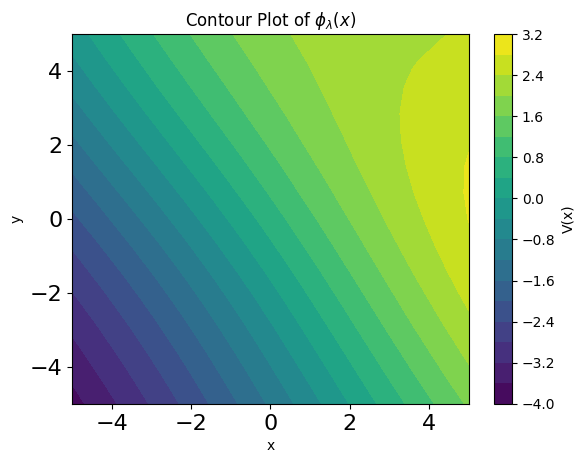

In [ ]:
# #Plot projection onto x-y
X,Y = np.meshgrid(x_grid,y_grid)
phi_slice = phi_plot[:,:,8]

fig = plt.figure()
contour = plt.contourf(X, Y, phi_slice, levels=20, cmap='viridis')
plt.colorbar(contour, label='V(x)')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of $\phi_\lambda(x)$')
fig.savefig('3D_contour.png')
plt.show()

In [ ]:
z_grid[8]

Array(0.71428571, dtype=float64)

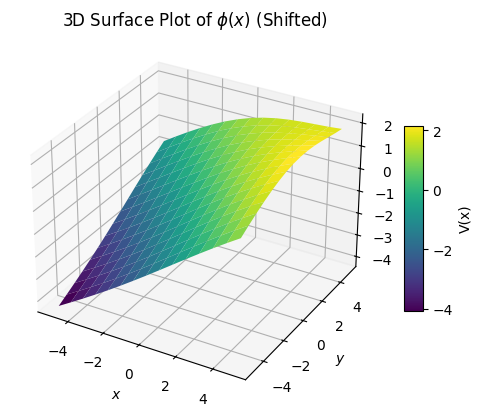

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
img = ax.plot_surface(X, Y, phi_slice,cmap=cm.viridis)
# img = ax.scatter3D(Xplot, Yplot, Vplot, c=h_approx, alpha=0.7, marker='.',cmap='viridis_r')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$v$')
ax.set_title(f'3D Surface Plot of $\phi(x)$ (Shifted)')
fig.colorbar(img, ax=ax, shrink=0.5, aspect=10, label='V(x)')